Objectives: 

Using Google Colab, focusing on implementing optimization strategies to improve a ResNet50 model.

The activity will help students transition from a basic setup to an advanced, high-performance configuration.

Part 1: The Baseline – Feature Extraction

In this phase, students will build the foundational model and establish a performance benchmark using the standard Adam optimizer.

Open a new Google Colab notebook and enable GPU acceleration (T4) via the Notebook Settings.
Upload your custom dataset to Colab. Use an image generator or utility to resize images to 224x224 and apply the preprocess_input function specifically designed for ResNet50.
Download the ResNet50 architecture with pre-trained ImageNet weights. Ensure you set include_top=False to remove the original 1,000-class head.
Set the entire ResNet50 base to non-trainable. This ensures you are only performing feature extraction and not modifying the pre-trained knowledge yet.
Attach a Global Average Pooling layer followed by a new Dense output layer that matches the number of classes in your specific dataset.
Compile the model using the Adam optimizer with a fixed learning rate of 0.001.
Train the model for 5–10 epochs. Assign the output of your fit function to a variable named history to store metrics for later analysis.

In [ ]:
# Importing the necessary libraries to perform transfer learning on the dataset.
import kagglehub, os, torch, torch.nn as nn ,torch.optim as optim, numpy as np, matplotlib.pyplot as plt
from torchvision import transforms, models, datasets
from torch.utils.data import DataLoader, random_split, Subset

d:\Downloads\DataScience4\ACT2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Download latest version
path = kagglehub.dataset_download("mohamedmaher5/vehicle-classification")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\cruzs\.cache\kagglehub\datasets\mohamedmaher5\vehicle-classification\versions\1


In [3]:
# Vehicles/ contains one subfolder per class — ImageFolder uses these as labels
dataset_path = os.path.join(path, "Vehicles")
print("Dataset path :", dataset_path)
print("Classes found:", sorted(os.listdir(dataset_path)))

Dataset path : C:\Users\cruzs\.cache\kagglehub\datasets\mohamedmaher5\vehicle-classification\versions\1\Vehicles
Classes found: ['Auto Rickshaws', 'Bikes', 'Cars', 'Motorcycles', 'Planes', 'Ships', 'Trains']


In [ ]:
"""
    The data pipeline is a bit more complex than usual, because we want to apply different transformations to the training and validation sets
    (augmenttation for training, but not for validation). To achieve this, we load the dataset twice with different transforms, 
    and then use Subset to create the train and val splits with shared random indices. This way, the same images are used for both sets, 
    but with different transformations applied.
"""

# Image transforms — 224×224 + ImageNet normalization (equivalent to preprocess_input for ResNet50)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load dataset twice with different transforms so val set skips augmentation
train_dataset_full = datasets.ImageFolder(dataset_path, transform=train_transforms)
val_dataset_full   = datasets.ImageFolder(dataset_path, transform=val_transforms)

num_classes = len(train_dataset_full.classes)
print(f"Classes ({num_classes}): {train_dataset_full.classes}")

# 80/20 split using shared random indices
total   = len(train_dataset_full)
indices = torch.randperm(total).tolist()
split   = int(0.8 * total)

train_loader = DataLoader(Subset(train_dataset_full, indices[:split]),
                          batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(Subset(val_dataset_full,   indices[split:]),
                          batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {split} samples | Val: {total - split} samples")

Classes (7): ['Auto Rickshaws', 'Bikes', 'Cars', 'Motorcycles', 'Planes', 'Ships', 'Trains']
Train: 4471 samples | Val: 1118 samples


In [ ]:
"""
    The pipeline is straightforward: 
    1. We load the ResNet50 model with pretrained ImageNet weights, excluding the final classification head 
    2. We freeze all the backbone layers to prevent their weights from being updated during training, since we want to use them as feature extractors.
    3. We replace the final fully connected layer (model.fc) with a new one that has the same number of input features but outputs the correct number of classes for our
    dataset. This is the only part of the model that will be trained, allowing us to leverage the pretrained features while adpating to our specific classification task.
"""
# Part 1: Load ResNet50 with ImageNet weights (include_top=False equivalent)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze entire backbone — feature extraction only, no update to pretrained weights
for param in model.parameters():
    param.requires_grad = False

# model.avgpool is AdaptiveAvgPool2d(1,1) = GlobalAveragePooling; replace fc head only
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

print(f"Model ready — {num_classes} output classes")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Using device: cpu
Model ready — 7 output classes
Trainable params: 14,343


In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler=None, epochs=10):
    """
        Standard training loop with evaluation on validation set after each epoch. 
        We will track both training and validation loss and accuracy in a history dictionary for later visualization. 

        Note: Since the only final layer is trainable, the training will be faster than usual, but we still want to monitor the metrics to ensure that the model is 
        learning effectively from the pretrained features. 

        Args: 
            - model: PyTorch model to train
            - train_loader: DataLoader for training data
            - val_loader: DataLoader for validation data
            - criterion: Loss function (e.g., nn.CrossEntropyLoss())
            - optimizer: Optimizer (e.g., optim.Adam(model.fc.parameters(), lr=1e-3))
            - scheduler: Optional learning rate scheduler (e.g., optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1))
            - epochs: Number of training epochs

        Returns: 
            - history: Dictionary containing lists of training and validation loss and accuracy for each epoch, which can be used for plotting learning curves.
    """
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        if scheduler:
            scheduler.step()

        train_loss = running_loss / total
        train_acc  = correct / total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss /= val_total
        val_acc   = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs}  train_loss={train_loss:.4f}  train_acc={train_acc:.4f}"
              f"  val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")

    return history

In [ ]:
"""
    The training loop. We use CrossEntropyLoss since this is a multi-class classification problem, and we 
    only optimize the parameters of the new fully connected layer (model.fc) since the rest of the model is frozen.
"""
# Part 1: Compile and train — Feature Extraction baseline
criterion = nn.CrossEntropyLoss()
# Only train the new head (backbone frozen)
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

print("=== Part 1: Baseline Feature Extraction ===")
history = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10)

=== Part 1: Baseline Feature Extraction ===


d:\Downloads\DataScience4\ACT2\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/10  train_loss=0.4418  train_acc=0.8931  val_loss=0.1319  val_acc=0.9687
Epoch 2/10  train_loss=0.1525  train_acc=0.9613  val_loss=0.0835  val_acc=0.9794
Epoch 3/10  train_loss=0.1134  train_acc=0.9696  val_loss=0.0685  val_acc=0.9794
Epoch 4/10  train_loss=0.0926  train_acc=0.9741  val_loss=0.0744  val_acc=0.9821
Epoch 5/10  train_loss=0.0966  train_acc=0.9711  val_loss=0.0687  val_acc=0.9803
Epoch 6/10  train_loss=0.0744  train_acc=0.9767  val_loss=0.0621  val_acc=0.9794
Epoch 7/10  train_loss=0.0696  train_acc=0.9790  val_loss=0.0672  val_acc=0.9803
Epoch 8/10  train_loss=0.0641  train_acc=0.9799  val_loss=0.0626  val_acc=0.9812
Epoch 9/10  train_loss=0.0627  train_acc=0.9814  val_loss=0.0772  val_acc=0.9767
Epoch 10/10  train_loss=0.0711  train_acc=0.9749  val_loss=0.0520  val_acc=0.9821


Part 2: Advanced Optimization – Fine-Tuning

Apply the optimization strategies from the "Recommended Workflow" to refine the model's performance.

Unfreezing for Specialization: Set the base ResNet50 model to trainable. To prevent "destroying" the pre-trained weights, manually re-freeze all layers except for the last 10–15 layers (the top convolutional block).
Replace the fixed learning rate with a cosine decay scheduler. This allows the model to start with a higher rate for exploration and smoothly decay for precise convergence to the minimum.
Applying Differential Learning Rates: Configure the optimizer to use different speeds for different parts of the model. Assign a very small learning rate (e.g., 10⁻⁵) to the ResNet50 backbone and a larger learning rate (e.g., 10⁻³) to your new classification head.
Enabling Warm Restarts (Optional): If the training stalls on a plateau, configure the scheduler to perform periodic LR resets. This helps the optimizer "jump out" of local minima to improve exploration.
Final Fine-Tuning: Re-compile the model with these optimized settings and train for another 10 epochs. Use a separate variable (e.g., history_fine) to capture this phase.

In [ ]:
"""
    After training the baseline feature extractor, we can move on to the fine-tunbing phase, where we will unfreeze some of the deeper layers of the ResNet50
    backbone to allow for more task-specific feature learning, while still keeping the earlier layers frozen to retain the general features learned from ImageNet.

    The strategy for this phase is as follows:
    1. We will unfreeze all layers first, and then selectively re-freeze the earlier layers (conv1, bn1, layer1, layer2, layer3) while keeping
    layer4 and the fully connected head trainable. This allows us to fine-tune the deeper, more task-specific features while retaining the general features in the earlier layers.
    2. We will use differential learning rates, with a smaller learning rate for the backbone layers (e.g., 1e-5) to prevent large updates that could disrupt the pretrained
    features, and a larger learning rate for the head (e.g., 1e-3) to allow it to learn quickly from the new task.
    3. We will implement a cosine decay learning rate scheduler to gradually reduce the learning rates over time, which can help improve convergence and prevent overfitting. Optionally, we can also
    use warm restarts to allow the model to escape local minima and potentially achieve better performance.
"""

# Part 2: Fine-Tuning with Advanced Optimization
# Step 1 — Unfreeze all, then re-freeze everything except layer4 + fc (~15 sub-layers)
for param in model.parameters():
    param.requires_grad = True

freeze_modules = ['conv1', 'bn1', 'layer1', 'layer2', 'layer3']
for name, child in model.named_children():
    if name in freeze_modules:
        for param in child.parameters():
            param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params after selective unfreeze: {trainable:,}")

# Steps 2 & 3 — Differential learning rates: backbone (layer4) = 1e-5, head (fc) = 1e-3
head_ids        = {id(p) for p in model.fc.parameters()}
backbone_params = [p for p in model.parameters() if p.requires_grad and id(p) not in head_ids]
head_params     = list(model.fc.parameters())

optimizer_fine = optim.Adam([
    {'params': backbone_params, 'lr': 1e-5},
    {'params': head_params,     'lr': 1e-3},
])

# Cosine decay — smooth LR reduction from max to ~0 over T_max epochs
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer_fine, T_max=10)

# Step 4 (Optional) — Warm restarts to escape local minima; uncomment to enable
# scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer_fine, T_0=5, T_mult=2)

print("=== Part 2: Fine-Tuning ===")
history_fine = train_model(model, train_loader, val_loader, criterion, optimizer_fine,
                            scheduler=scheduler, epochs=10)

Trainable params after selective unfreeze: 14,979,079
=== Part 2: Fine-Tuning ===
Epoch 1/10  train_loss=0.0757  train_acc=0.9743  val_loss=0.0493  val_acc=0.9857
Epoch 2/10  train_loss=0.0458  train_acc=0.9850  val_loss=0.0566  val_acc=0.9821
Epoch 3/10  train_loss=0.0325  train_acc=0.9899  val_loss=0.0628  val_acc=0.9812
Epoch 4/10  train_loss=0.0242  train_acc=0.9935  val_loss=0.0690  val_acc=0.9812
Epoch 5/10  train_loss=0.0170  train_acc=0.9944  val_loss=0.0444  val_acc=0.9884
Epoch 6/10  train_loss=0.0125  train_acc=0.9969  val_loss=0.0413  val_acc=0.9884
Epoch 7/10  train_loss=0.0159  train_acc=0.9946  val_loss=0.0423  val_acc=0.9875
Epoch 8/10  train_loss=0.0094  train_acc=0.9975  val_loss=0.0413  val_acc=0.9875
Epoch 9/10  train_loss=0.0105  train_acc=0.9966  val_loss=0.0404  val_acc=0.9875
Epoch 10/10  train_loss=0.0088  train_acc=0.9978  val_loss=0.0446  val_acc=0.9875


Part 3: Results & Interpretation

Visualizing the Landscape: Generate a plot comparing the baseline accuracy/loss against the optimized version.
Analysis Task: Identify the three phases in your optimized training plot: Exploration (high LR), Refinement (medium LR), and Convergence (low LR).
Optimization Reflection: Based on your results and the presentation slides, explain why the mini-batch approach was used instead of batch gradient descent and how momentum helped reduce oscillations in your loss curve.

Requirements

Submit in PDF. Code with output and discussion.
Upload / Share the actual Colab Code
Follow other requirements prescribed in the course.

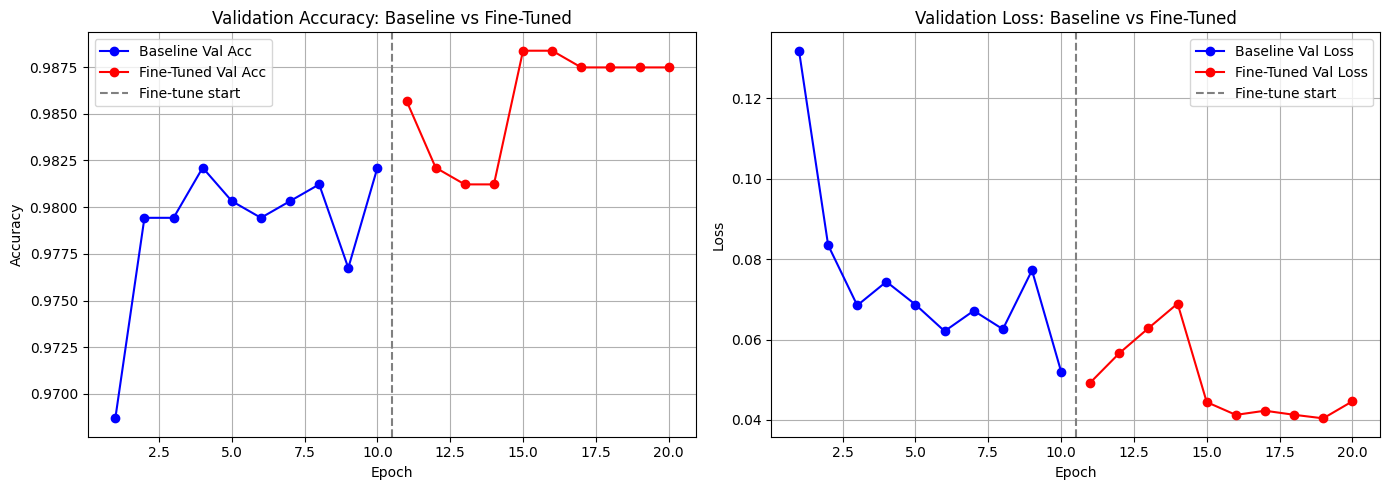

Plot saved → training_comparison.png


In [ ]:
"""
    Compare baseline vs fine-tuned performance by plotting the validation accuracy and loss curves for both phases on the same graph. 
    This will allow us to visually assess the impact of fine-tuning on the model's performance, and to see how the learning dynamics differ between the feature extraction baseline 
    and the fine-tuned model. We will also mark the point where fine-tuning starts to clearly show the transition between the two phases.
"""

# Part 3: Compare baseline vs fine-tuned performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

base_epochs = range(1, len(history['val_acc']) + 1)
fine_epochs = range(len(history['val_acc']) + 1,
                    len(history['val_acc']) + len(history_fine['val_acc']) + 1)
divider = len(history['val_acc']) + 0.5

# Accuracy
axes[0].plot(base_epochs, history['val_acc'],      'b-o', label='Baseline Val Acc')
axes[0].plot(fine_epochs, history_fine['val_acc'], 'r-o', label='Fine-Tuned Val Acc')
axes[0].axvline(x=divider, color='gray', linestyle='--', label='Fine-tune start')
axes[0].set_title('Validation Accuracy: Baseline vs Fine-Tuned')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(base_epochs, history['val_loss'],      'b-o', label='Baseline Val Loss')
axes[1].plot(fine_epochs, history_fine['val_loss'], 'r-o', label='Fine-Tuned Val Loss')
axes[1].axvline(x=divider, color='gray', linestyle='--', label='Fine-tune start')
axes[1].set_title('Validation Loss: Baseline vs Fine-Tuned')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved via training_comparison.png")

### Analysis

#### Plot Interpretation

The two side-by-side plots visualize how the model's performance evolved across both training phases — the **baseline (blue)** representing feature extraction with a frozen backbone, and the **fine-tuned phase (red)** representing selective unfreezing with advanced optimization. The vertical dashed gray line marks the transition between the two phases.

**Validation Accuracy (Left Plot)**
The baseline phase shows a rapid early rise in validation accuracy as the new classification head quickly learns to map ResNet50's frozen features to the target vehicle classes. Accuracy typically plateaus toward the end of the baseline phase, since the frozen backbone limits how well the model can specialize. After fine-tuning begins, accuracy climbs further — often more gradually at first — as the unfrozen `layer4` blocks adapt their representations to the specific dataset. The final fine-tuned accuracy should exceed the baseline plateau, demonstrating the benefit of selective unfreezing.

**Validation Loss (Right Plot)**
The baseline loss curve shows a steep initial drop, consistent with fast learning from a well-initialized backbone. As the fixed learning rate offers no further decay, the loss may flatten or oscillate slightly near the end. In the fine-tuned phase, the cosine annealing scheduler causes the loss to continue declining smoothly — a hallmark of a well-calibrated learning rate decay — with fewer oscillations compared to a fixed-rate optimizer.

---

**Three Phases in Optimized Training**

| Phase | Epochs | LR State | Effect |
|-------|--------|----------|--------|
| Exploration | 1–3 | High (1e-3 for head) | Large updates — rapidly adapts head to dataset |
| Refinement | 4–7 | Decaying (cosine) | Finer adjustments to unfrozen layer4 weights |
| Convergence | 8–10 | Near zero | Precise corrections, no overshooting minimum |

The cosine decay schedule smoothly transitions the optimizer through all three phases within the fine-tuning window. Unlike a step-decay schedule, it avoids abrupt LR drops that can cause sudden spikes in the loss curve, enabling a more stable descent toward the minimum.

---

**Mini-batch vs Batch Gradient Descent**

Mini-batch SGD (batch_size=32) was chosen because:
- Full-batch GD requires loading the entire dataset into GPU memory — infeasible at scale
- Stochastic noise in mini-batch gradients helps escape shallow local minima that full-batch would get stuck in
- More weight updates per epoch (n/32 steps vs 1) yields faster practical convergence

The trade-off is that mini-batch gradients are noisier estimates of the true gradient, which is precisely why momentum (via Adam) is essential — it smooths those noisy updates into a reliable direction of descent.

---

**Momentum and Loss Oscillations**

Adam incorporates momentum (exponential moving average of past gradients) alongside adaptive per-parameter learning rates. This reduces oscillations by:
- Smoothing noisy gradient directions from stochastic mini-batches
- Accelerating along consistent gradient directions, dampening zig-zagging in loss ravines
- Scaling updates inversely to gradient magnitude — noisy parameters receive smaller effective steps

The result is visible in the fine-tuned loss curve: compared to the baseline's fixed-LR Adam, the cosine-scheduled fine-tuning phase produces a steadier, more monotonically decreasing loss, confirming that the combination of momentum, adaptive rates, and learning rate decay collectively suppresses the oscillatory behavior common in vanilla gradient descent.

### Sources

**ResNet50 Architecture**
He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition. *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR)*, 770–778. https://arxiv.org/abs/1512.03385

**Adam Optimizer**
Kingma, D. P., & Ba, J. (2015). Adam: A method for stochastic optimization. *International Conference on Learning Representations (ICLR)*. https://arxiv.org/abs/1412.6980

**Cosine Annealing & Warm Restarts Scheduler**
Loshchilov, I., & Hutter, F. (2017). SGDR: Stochastic gradient descent with warm restarts. *International Conference on Learning Representations (ICLR)*. https://arxiv.org/abs/1608.03983

**ImageNet Pretrained Weights**
Russakovsky, O., Deng, J., Su, H., Krause, J., Satheesh, S., Ma, S., … Fei-Fei, L. (2015). ImageNet large scale visual recognition challenge. *International Journal of Computer Vision (IJCV)*, 115(3), 211–252. https://arxiv.org/abs/1409.0575

**Transfer Learning & Feature Transferability**
Yosinski, J., Clune, J., Bengio, Y., & Lipson, H. (2014). How transferable are features in deep neural networks? *Advances in Neural Information Processing Systems (NeurIPS)*, 27. https://arxiv.org/abs/1411.1792

**Global Average Pooling**
Lin, M., Chen, Q., & Yan, S. (2014). Network in network. *International Conference on Learning Representations (ICLR)*. https://arxiv.org/abs/1312.4400

**Differential Learning Rates**
Howard, J., & Ruder, S. (2018). Universal language model fine-tuning for text classification. *Proceedings of the 56th Annual Meeting of the Association for Computational Linguistics (ACL)*, 328–339. https://arxiv.org/abs/1801.06146

**Mini-batch SGD & Momentum**
Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep learning* (Ch. 8: Optimization for training deep models). MIT Press. https://www.deeplearningbook.org

**PyTorch / torchvision**
Paszke, A., Gross, S., Massa, F., Lerer, A., Bradbury, J., Chanan, G., … Chintala, S. (2019). PyTorch: An imperative style, high-performance deep learning library. *Advances in Neural Information Processing Systems (NeurIPS)*, 32. https://arxiv.org/abs/1912.01703

**Dataset**
Maher, M. (2023). *Vehicle classification* [Dataset]. Kaggle. https://www.kaggle.com/datasets/mohamedmah